# Histogram binning during image reconstruction

Binning in the context of this notebook combines several adjacent TCSPC bins into one wider bin, Δt. It can be useful when unnecessarily high temporal hardware resolution was used. The original TCSPC resolution is stored in the `.ptu` header as the `MeasDesc_Resolution` parameter.

Binning does not increase the number of detected photons or the fundamental information contained in the data. Instead, it provides a lower-dimensional representation in which each histogram bin contains more photons and therefore has better counting statistics, at the cost of temporal resolution. *The reconstructor class applies binning only to the reconstructed histogram*.

For moderate binning factors, the effect on derived quantities such as mean photon arrival time and phasor coordinates should be small, provided that the resulting bin width remains sufficiently small compared with the relevant temporal features. The mean arrival time can be affected by the temporal quantization introduced by assigning photons to wider bins. Similarly, phasor coordinates can experience a small sampling-dependent phase shift and, for sufficiently large bins, a small attenuation.

The effect of binning on the phasor is illustrated in this notebook.

Read image acquired with mono-directional scan

In [52]:
from tttrkit.ptuio.reader import TTTRReader


reader = TTTRReader('../../data/MultiHarp150_2025-07-09_17-16-49.326_500px_1accu_STAR488.ptu')
for key, value in reader.header.tags.items():
    print(f'{key}: {value}')


TTResult_StopReason: 0
File_Comment: N/A
File_CreatingTime: 2025-07-09 17:16:49.327000
CreatorSW_Name: Imspector
Measurement_Mode: 3
Measurement_SubMode: 3
$StartedByRemoteInterface: False
CreatorSW_Version: 16.3.21879-w2448
File_GUID: {55649314-F047-4117-AEA5-AD0C77ECE39E}
Fast_Load_End: <Empty>
CreatorSW_SVNBuild: 21879
HW_Type: MultiHarp 150 4P
HW_Version: 1.0
HW_PartNo: 930043
HW_SerialNo: 1050703
HW_Features: 183
ImgHdr_Frame: 3
ImgHdr_LineStart: 1
ImgHdr_LineStop: 2
MeasDesc_AcquisitionTime: 25400
ImgHdr_PixX: 500
ImgHdr_PixY: 500
ImgHdr_TimePerPixel: 0.1
UsrAI_usrTagVersion: 1.0.0
UsrAIScanAx_Label[0]: ExpControl X
ImgHdr_X0: -28.273451861375392
UsrAIScanAx_Label[1]: ExpControl Y
ImgHdr_Y0: -28.374270786792945
ImgHdr_PixResol: 0.1
UsrAI_ScanAxes: 2
ImgHdr_BiDirect: False
ImgHdr_Dimensions: 3
ImgHdr_Ident: 13
HW_BaseResolution: 5e-12
MeasDesc_GlobalResolution: 2.5000068750189064e-08
MeasDesc_Resolution: 5e-12
MeasDesc_BinningFactor: 1
MeasDesc_Offset: 0
MeasDesc_Restart: False
Me

Here the image data is saved in the header, but accumulations and sequence configuration is not. So it must be known or guessed...

In [53]:

Measurement_SubMode = reader.header.tags.get("Measurement_SubMode")

if Measurement_SubMode<1: 
    print("Not an image. You must set scanning configuration.")
else:
    ImgHdr_PixX = reader.header.tags.get("ImgHdr_PixX")
    ImgHdr_PixY = reader.header.tags.get("ImgHdr_PixY")
    print("Number of pixels from header: ", ImgHdr_PixX)
    print("Number of lines from the header: ", ImgHdr_PixY)
    # Number of lines is only correct for 1 sequence + 1 accumulation


Number of pixels from header:  500
Number of lines from the header:  500


Define scanning configuration

In [54]:
from tttrkit.ptuio.utils import estimate_tcspc_bins
from tttrkit.ptuio.decoder import T3OverflowCorrector
from tttrkit.ptuio.reconstructor import ScanConfig, ImageReconstructor

import numpy as np

bin_factor = 16


cfg = ScanConfig(
    bidirectional=False, 
    frames= 1,
    lines=500, 
    pixels=500, 
    line_accumulations= (1,),
    max_detector=1,
    )

wrap = reader.header.tags.get("TTResultFormat_WrapAround", 1024)  # default fallback
repetition_rate = reader.header.tags.get("TTResult_SyncRate",40e6)  
tcspc_resolution = reader.header.tags.get("MeasDesc_Resolution",5e-12)
tcspc_bins = estimate_tcspc_bins(reader.header.tags,buffer=100) # for high resolution (<10ps), tcspcs channel overflow can be expected -> set higher buffer

corrector = T3OverflowCorrector(wraparound=wrap)


In [55]:
def random_boolean_mask(
    x: int, y: int, n_true: int, rng: np.random.Generator | None = None
) -> np.ndarray:
    """Create a random boolean mask of shape (y, x) with exactly n_true True pixels."""
    total = x * y
    if not (0 <= n_true <= total):
        raise ValueError(f"n_true must be between 0 and {total}")

    if rng is None:
        rng = np.random.default_rng()

    mask = np.zeros(total, dtype=bool)
    true_idx = rng.choice(total, size=n_true, replace=False)
    mask[true_idx] = True
    return mask.reshape(y, x)


In [56]:
from tttrkit.analysis.phasor import get_phasor_from_decay
from tttrkit.analysis.decay import shift_decay

decay = []
decay_binned = []
decay_shifted = []
phasor = []
phasor_binned = []
phasor_shifted = []

for i in np.arange(10):

    # generate random mask
    mask = random_boolean_mask(500,500,1000)

    # reconstruct unbinned histogram
    reconstructor = ImageReconstructor(
            config=cfg, 
            laser_sync_rate=repetition_rate, 
            tcspc_channels= tcspc_bins,
            tcspc_resolution=tcspc_resolution,
            outputs=["tcspc_histogram"],
            roi_mask=mask,
            )

    for chunk in reader.iter_chunks():
        corrected_chunk = corrector.correct(chunk)
        reconstructor.update(corrected_chunk)

    result = reconstructor.finalize()

    decay.append(result.tcspc_histogram.isel(channel=0,sequence=0,frame=0).values)
    phasor.append(get_phasor_from_decay(
        decay=result.tcspc_histogram.isel(channel=0,sequence=0,frame=0).values,
        tcspc_resolution=result.tcspc_resolution.values,
        sync_rate=repetition_rate,
    ))

    
    decay_shifted.append(
        shift_decay(result.tcspc_histogram.isel(channel=0,sequence=0,frame=0).values,int(bin_factor / 2))
    )

    phasor_shifted.append(get_phasor_from_decay(
        shift_decay(result.tcspc_histogram.isel(channel=0,sequence=0,frame=0).values,int(bin_factor / 2)),
        tcspc_resolution=result.tcspc_resolution.values,
        sync_rate=repetition_rate,

    ))
    

    # reconstruct binned histogram
    reconstructor = ImageReconstructor(
            config=cfg, 
            laser_sync_rate=repetition_rate, 
            tcspc_channels= tcspc_bins,
            tcspc_resolution=tcspc_resolution,
            tcspc_bin_factor=bin_factor,
            outputs=["tcspc_histogram"],
            roi_mask=mask,
            )

    for chunk in reader.iter_chunks():
        corrected_chunk = corrector.correct(chunk)
        reconstructor.update(corrected_chunk)

    result_binned = reconstructor.finalize()

    decay_binned.append(result_binned.tcspc_histogram.isel(channel=0,sequence=0,frame=0).values)
    phasor_binned.append(get_phasor_from_decay(
        decay=result_binned.tcspc_histogram.isel(channel=0,sequence=0,frame=0).values,
        tcspc_resolution=result_binned.tcspc_resolution.values,
        sync_rate=repetition_rate,
    ))





Reconstruction finished.
Reconstruction finished.
Reconstruction finished.
Reconstruction finished.
Reconstruction finished.
Reconstruction finished.
Reconstruction finished.
Reconstruction finished.
Reconstruction finished.
Reconstruction finished.
Reconstruction finished.
Reconstruction finished.
Reconstruction finished.
Reconstruction finished.
Reconstruction finished.
Reconstruction finished.
Reconstruction finished.
Reconstruction finished.
Reconstruction finished.
Reconstruction finished.


In [57]:
# from tttrkit.analysis.visualization import create_FLIM_image
# import matplotlib.pyplot as plt
# import matplotlib.colors as mcolors
# colormap = mcolors.LinearSegmentedColormap.from_list("green_red", ["lime", "magenta"])
# # colormap = mcolors.

# lt_min = 1 
# lt_max = 5

# FLIM_image = create_FLIM_image(mean_photon_arrival_time=result.mean_arrival_time.isel(frame=0,sequence=0,channel=0).values * result.tcspc_resolution.values * 1e9, 
#                                intensity=result.photon_count.isel(frame=0,sequence=0,channel=0).values, 
#                                lt_min = lt_min, 
#                                lt_max = lt_max,
#                                int_min=0,
#                                int_max=50,
#                                colormap=colormap,
#                                )

# FLIM_image_binned = create_FLIM_image(mean_photon_arrival_time=result_binned.mean_arrival_time.isel(frame=0,sequence=0,channel=0).values * result_binned.tcspc_resolution.values * 1e9, 
#                                intensity=result_binned.photon_count.isel(frame=0,sequence=0,channel=0).values, 
#                                lt_min = lt_min, 
#                                lt_max = lt_max,
#                                int_min=0,
#                                int_max=50,
#                                colormap=colormap
#                                )

# fig, ax = plt.subplots(1,2)
# img = ax[0].imshow(FLIM_image, cmap = colormap,vmin=lt_min, vmax=lt_max, interpolation='nearest')
# ax[0].set_title('No TCSPC binning')
# ax[0].axis("off")
# ax[1].imshow(FLIM_image_binned, cmap = colormap,vmin=lt_min, vmax=lt_max, interpolation='nearest')
# ax[1].set_title(f'TCSPC binning {bin_factor}x')
# ax[1].axis("off")


# fig.colorbar(img, ax=ax[0], fraction=0.046, pad=0.04)
# fig.colorbar(img, ax=ax[1], fraction=0.046, pad=0.04)

# plt.tight_layout()
# plt.show()

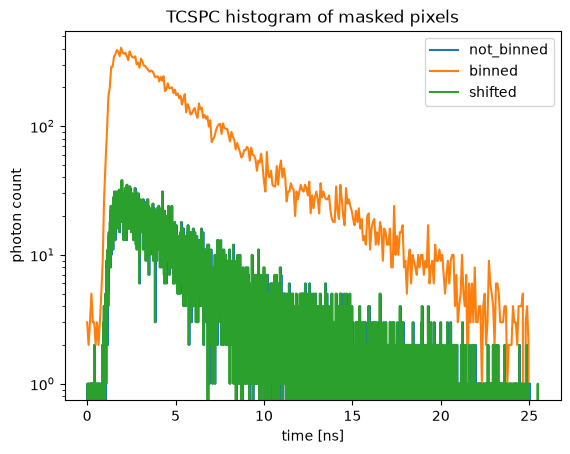

In [58]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.semilogy(
    result.tcspc_time.values * 1e9,
    decay[0],
    label='not_binned',
    )

ax.semilogy(
    result_binned.tcspc_time.values * 1e9,
    decay_binned[0],
    label='binned',
    )

ax.semilogy(
    result.tcspc_time.values * 1e9,
    decay_shifted[0],
    label='shifted'
)

ax.set_xlabel('time [ns]')
ax.set_ylabel('photon count')
ax.legend()
plt.title("TCSPC histogram of masked pixels")
plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


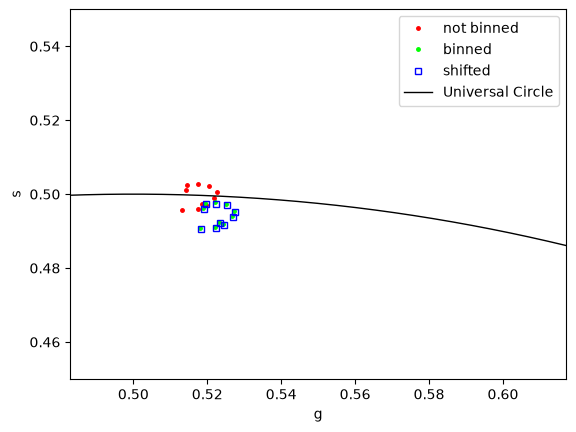

In [59]:
from tttrkit.analysis.visualization import draw_unitary_circle

calibration = 1.009 -0.362j


phasor_array = np.array(phasor) * calibration
phasor_binned_array = np.array(phasor_binned) * calibration
phasor_shifted_array = np.array(phasor_shifted) * calibration

fig, ax = plt.subplots()
ax.plot(
    phasor_array.real,
    phasor_array.imag,
    marker = '.',
    markersize=5,
    color='r',
    linestyle='none',
    label='not binned'
)

ax.plot(
    phasor_binned_array.real,
    phasor_binned_array.imag,
    marker = '.',
    markersize=5,
    color='lime',
    linestyle='none',
    label='binned'
)

ax.plot(
    phasor_shifted_array.real,
    phasor_shifted_array.imag,
    marker = 's',
    markersize=5,
    color='none',
    markeredgecolor='blue',
    linestyle='none',
    label='shifted'
)


draw_unitary_circle(ax,repetition_rate, tau_max=5,color='black',
                    xlim=(.5,.6),
                    ylim=(.45,.55),

                    )

ax.legend()
plt.show()